In [2]:
import pandas as pd

# Create synthetic loan eligibility dataset
data = {
    "ApplicantIncome": [5849,4583,3000,6000,2500,4000,3200,5000,2700,3500,
                        4500,5200,6100,2900,3300,4100,3700,4800,5400,6200,
                        2800,3600,4300,3900,4700,5300,6000,3100,3400,4200,
                        3800,4600,5100,5900,2950,3250,4050,3750,4550,5250],
    "CoapplicantIncome": [0,1508,0,0,2000,1500,0,1800,0,1200,
                          0,1600,0,0,1200,0,1500,0,1700,0,
                          0,1400,0,0,1600,0,1800,0,1300,0,
                          0,1500,0,1700,0,1400,0,0,1600,0],
    "LoanAmount": [146,128,66,120,100,150,80,200,90,110,
                   130,140,160,70,95,125,105,135,145,155,
                   85,115,125,95,140,150,165,75,100,120,
                   110,130,140,160,80,105,115,90,135,145],
    "Loan_Amount_Term": [360]*40,
    "Credit_History": [1,1,1,1,0,1,1,0,1,1,
                       1,1,1,0,1,1,1,1,0,1,
                       1,1,1,0,1,1,1,1,0,1,
                       1,1,1,0,1,1,1,1,0,1],
    "Gender": ["Male","Male","Male","Female","Male","Female","Male","Male","Female","Male",
               "Male","Male","Female","Male","Male","Female","Male","Male","Male","Female",
               "Male","Male","Female","Male","Male","Female","Male","Male","Male","Female",
               "Male","Male","Female","Male","Male","Female","Male","Male","Female","Male"],
    "Married": ["No","Yes","Yes","Yes","No","Yes","No","Yes","No","Yes",
                "Yes","No","Yes","No","Yes","Yes","No","Yes","Yes","No",
                "Yes","No","Yes","No","Yes","Yes","No","Yes","No","Yes",
                "No","Yes","Yes","No","Yes","No","Yes","No","Yes","No"],
    "Education": ["Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate",
                  "Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate",
                  "Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate",
                  "Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate","Graduate"],
    "Self_Employed": ["No","No","Yes","No","No","No","No","Yes","No","No",
                      "No","No","No","Yes","No","No","No","No","Yes","No",
                      "No","No","No","Yes","No","No","No","No","Yes","No",
                      "No","No","No","Yes","No","No","No","No","Yes","No"],
    "Property_Area": ["Urban","Rural","Urban","Semiurban","Rural","Urban","Semiurban","Rural","Urban","Semiurban",
                      "Urban","Rural","Semiurban","Urban","Semiurban","Rural","Urban","Semiurban","Rural","Urban",
       
                      "Semiurban","Urban","Rural","Semiurban","Urban","Rural","Urban","Semiurban","Rural","Urban",
                      "Semiurban","Urban","Rural","Semiurban","Urban","Semiurban","Rural","Urban","Semiurban","Rural"],
    "Loan_Status": [1,0,1,1,0,1,1,0,1,1,
                    1,1,1,0,1,1,1,1,0,1,
                    1,1,1,0,1,1,1,1,0,1,
                    1,1,1,0,1,1,1,1,0,1]
}

df = pd.DataFrame(data)
print(df)
df.to_csv("loan_eligibility.csv", index=False)



    ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0              5849                  0         146               360   
1              4583               1508         128               360   
2              3000                  0          66               360   
3              6000                  0         120               360   
4              2500               2000         100               360   
5              4000               1500         150               360   
6              3200                  0          80               360   
7              5000               1800         200               360   
8              2700                  0          90               360   
9              3500               1200         110               360   
10             4500                  0         130               360   
11             5200               1600         140               360   
12             6100                  0         160              

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve   # 1.importing of libraries

In [4]:
#2.Load the data set
df=pd.read_csv("loan_eligibility.csv")
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
0,5849,0,146,360,1,Male,No,Graduate,No,Urban,1
1,4583,1508,128,360,1,Male,Yes,Graduate,No,Rural,0
2,3000,0,66,360,1,Male,Yes,Graduate,Yes,Urban,1
3,6000,0,120,360,1,Female,Yes,Graduate,No,Semiurban,1
4,2500,2000,100,360,0,Male,No,Graduate,No,Rural,0


Loan_Status
1    31
0     9
Name: count, dtype: int64


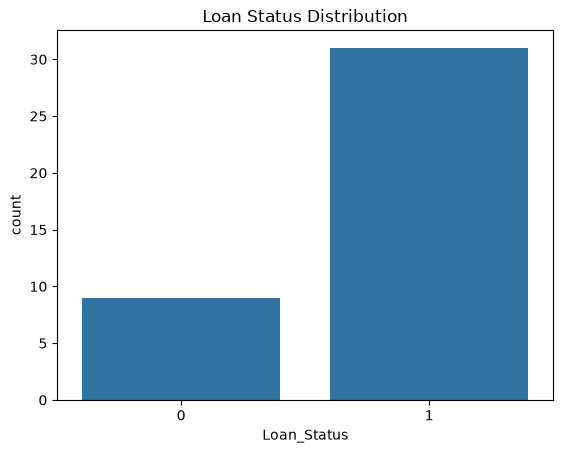

Categorical: ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
Numerical: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status']


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19144\2530716648.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features=df.select_dtypes(include=['object']).columns.tolist()


In [5]:
#exploratory data analysis (EDA)
print(df['Loan_Status'].value_counts())
sns.countplot(x='Loan_Status',data=df)
plt.title('Loan Status Distribution')
plt.show()

categorical_features=df.select_dtypes(include=['object']).columns.tolist()
numerical_features=df.select_dtypes(include=['int64','float64']).columns.tolist()

print('Categorical:',categorical_features)
print('Numerical:',numerical_features)

In [6]:
data1=df.drop(columns="Loan_Amount_Term",inplace=False)
data1.head()#Data preprocessing

,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
0,5849,0,146,1,Male,No,Graduate,No,Urban,1
1,4583,1508,128,1,Male,Yes,Graduate,No,Rural,0
2,3000,0,66,1,Male,Yes,Graduate,Yes,Urban,1
3,6000,0,120,1,Female,Yes,Graduate,No,Semiurban,1
4,2500,2000,100,0,Male,No,Graduate,No,Rural,0


In [7]:
df.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender', 'Married', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [8]:
df["Gender"] = pd.get_dummies(df["Gender"], drop_first=True, dtype=int)

In [9]:
df["Married"]=pd.get_dummies(df["Married"], drop_first=True, dtype=int)

In [10]:
df["Education"]=pd.get_dummies(df["Education"], dtype=int)

In [11]:
df["Self_Employed"]=pd.get_dummies(df["Self_Employed"], drop_first=True, dtype=int)

In [12]:
df = pd.get_dummies(df, columns=["Property_Area"], drop_first=False, dtype=int)

In [13]:
df.filter(like="Property_Area").columns

Index(['Property_Area_Rural', 'Property_Area_Semiurban',
       'Property_Area_Urban'],
      dtype='str')

In [14]:
df["Loan_Status"]=pd.get_dummies(df["Loan_Status"], drop_first=True,dtype=int)

In [15]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender,Married,Education,Self_Employed,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,5849,0,146,360,1,1,0,1,0,1,0,0,1
1,4583,1508,128,360,1,1,1,1,0,0,1,0,0
2,3000,0,66,360,1,1,1,1,1,1,0,0,1
3,6000,0,120,360,1,0,1,1,0,1,0,1,0
4,2500,2000,100,360,0,1,0,1,0,0,1,0,0


In [16]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender,Married,Education,Self_Employed,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,5849,0,146,360,1,1,0,1,0,1,0,0,1
1,4583,1508,128,360,1,1,1,1,0,0,1,0,0
2,3000,0,66,360,1,1,1,1,1,1,0,0,1
3,6000,0,120,360,1,0,1,1,0,1,0,1,0
4,2500,2000,100,360,0,1,0,1,0,0,1,0,0


In [17]:
x=df.drop(columns=["Loan_Status","Loan_Amount_Term"])

In [18]:
y=df["Loan_Status"]

In [19]:
print(x.shape)


(40, 11)


In [20]:
print(y.shape)

(40,)


In [21]:
print(y.value_counts())

Loan_Status
1    31
0     9
Name: count, dtype: int64


In [22]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)
#Train Test Split

In [23]:
x_test.shape

(12, 11)

In [24]:
x_train.shape

(28, 11)

In [25]:
df.Loan_Status.unique()

array([1, 0])

In [26]:
df.LoanAmount.unique()

array([146, 128,  66, 120, 100, 150,  80, 200,  90, 110, 130, 140, 160,
        70,  95, 125, 105, 135, 145, 155,  85, 115, 165,  75])

In [27]:
#Logistic Regression model training
model = LogisticRegression(max_iter=40,random_state=42)
model.fit(x_train, y_train)

C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 40 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=40).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",40
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfg

In [28]:
#Model Evaluation
y_pred =model.predict(x_test)
y_proba=model.predict_proba(x_test)[:, 1]

print('Accuracy:',accuracy_score(y_test,y_pred))
print('\nClassification Report:\n', classification_report(y_test,y_pred))

Accuracy: 0.9166666666666666

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.90      1.00      0.95         9

    accuracy                           0.92        12
   macro avg       0.95      0.83      0.87        12
weighted avg       0.92      0.92      0.91        12



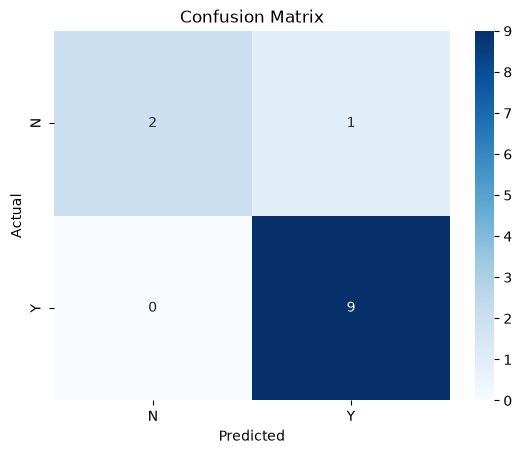

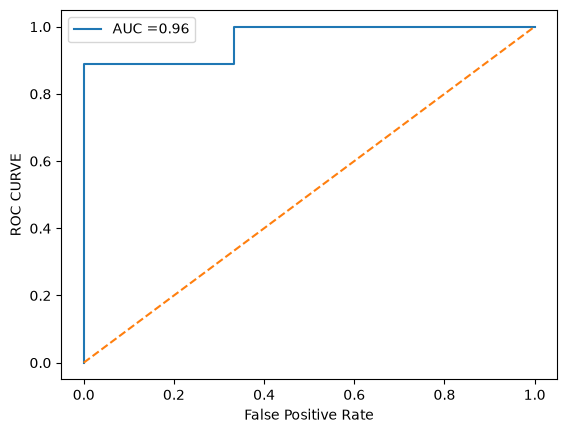

ROC AUC Score: 0.96


In [29]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['N','Y'],yticklabels=['N','Y'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

auc = roc_auc_score(y_test,y_proba)
fpr,tpr,thresholds =roc_curve(y_test,y_proba)
plt.plot(fpr,tpr,label=f'AUC ={auc:.2f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('ROC CURVE')
plt.legend()
plt.show()
print(f'ROC AUC Score: {auc:.2f}')

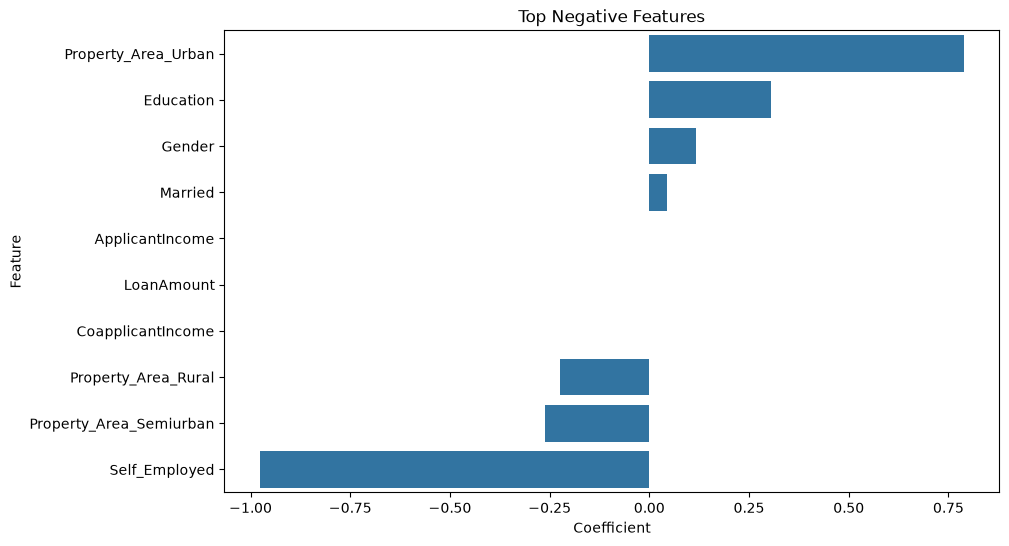

In [30]:
#Feature Importance (Coefficient Analysis)
coeffs = pd.DataFrame({
    'Feature':x.columns,
    'Coefficient':model.coef_[0]
}).sort_values(by='Coefficient',ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient',y='Feature',data=coeffs.tail(10))
plt.title('Top Negative Features')
plt.show()